In [1]:
import numpy as np
import napari
import nibabel as nib
import matplotlib.pyplot as plt
from skimage.measure import label
from skimage.morphology import remove_small_objects

In [2]:
api = np.load("../Stelzer_Torsten/npys/capsule_1a.npy") == 2

In [3]:
slice = api[450:550, :, :]

In [25]:
%gui qt6
napari.view_image(api[450:550, :, :])

Viewer(camera=Camera(center=(0.0, np.float64(432.0), np.float64(373.5)), zoom=np.float64(1.127807486631016), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(49.0), 1.0, 0.0), scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=3, ndisplay=2, order=(0, 1, 2), axis_labels=('0', '1', '2'), rollable=(True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(99.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(864.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(747.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(np.float64(49.0), np.float64(432.0), np.float64(373.0)), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False, spacin

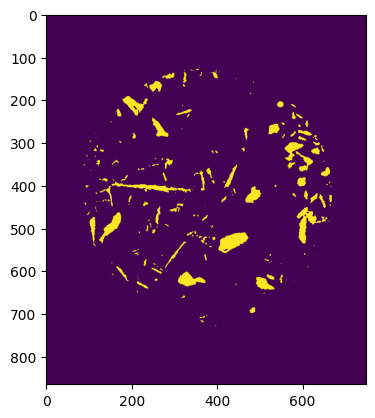

In [4]:
plt.imshow(slice[50])

In [5]:
def filter(array, min_size=512):
    labeled = label(array)
    
    labels_face_start = np.unique(labeled[0, :, :])
    labels_face_end = np.unique(labeled[-1, :, :])
    
    border_labels = np.union1d(labels_face_start, labels_face_end)
    border_labels = border_labels[border_labels != 0]
    border_mask = np.isin(labeled, border_labels)
    cleared_array = array.copy()
    cleared_array[border_mask] = 0
    
    cleared_array_bool = cleared_array.astype(bool)
    final_array = remove_small_objects(cleared_array_bool, min_size=min_size)
    return final_array

In [ ]:
slice = api[675:1000, :, :]
filtered = filter(slice)

In [24]:
viewer = napari.Viewer()
viewer.add_image(filtered)
viewer.add_image(slice)

<Image layer 'slice' at 0x3f002c830>

In [10]:
labels = label(filtered)
indices = np.where(labels == labels[98, 633, 422])
onecrystal = np.zeros_like(filtered)
onecrystal[indices] = 1

In [19]:
napari.view_image(onecrystal[40:145, 500:, 350:600])

Viewer(camera=Camera(center=(0.0, np.float64(182.0), np.float64(124.5)), zoom=np.float64(3.081643835616438), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(52.0), 1.0, 0.0), scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=3, ndisplay=2, order=(0, 1, 2), axis_labels=('0', '1', '2'), rollable=(True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(104.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(364.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(249.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(np.float64(52.0), np.float64(182.0), np.float64(124.0)), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False, spaci

In [15]:
napari.view_image(api)

Viewer(camera=Camera(center=(0.0, np.float64(432.0), np.float64(373.5)), zoom=np.float64(1.127807486631016), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(973.0), 1.0, 0.0), scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=3, ndisplay=2, order=(0, 1, 2), axis_labels=('0', '1', '2'), rollable=(True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(1947.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(864.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(747.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(np.float64(973.0), np.float64(432.0), np.float64(373.0)), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False, sp